# Importing Libraries

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.config import *

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
    SelectFromModel
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

import joblib

import warnings
warnings.filterwarnings("ignore")

# Loading Preprocessed Artifacts

In [3]:
X_train = joblib.load(
    ARTIFACT_DIR / "X_train.pkl"
)

X_test = joblib.load(
    ARTIFACT_DIR / "X_test.pkl"
)

y_train = joblib.load(
    ARTIFACT_DIR / "y_train.pkl"
)

y_test = joblib.load(
    ARTIFACT_DIR / "y_test.pkl"
)

selected_features = joblib.load(
    ARTIFACT_DIR / "selected_features.pkl"
)

print(X_train.shape)

(104, 33519)


# ANOVA F-Test

## Running ANOVA & getting scores

In [5]:
k_values = [50, 100, 250, 500]

anova_results = {}

for k in k_values:

    selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = selector.fit_transform(
        X_train,
        y_train
    )

    selected_indices = selector.get_support(indices=True)

    selected_genes = selected_features[selected_indices]

    scores = selector.scores_[selected_indices]

    selected_df = pd.DataFrame({
        "gene": selected_genes,
        "anova_score": scores
    })

    selected_df = selected_df.sort_values(
        by="anova_score",
        ascending= True
    )

    anova_results[k] = selected_df

    print(f"\nTop genes for k={k}")
    print(selected_df.head(10))


Top genes for k=50
           gene  anova_score
14    209603_at    88.850815
9     205967_at    88.895729
46    236641_at    90.040169
37    226192_at    90.141899
38    226197_at    90.556602
31    222039_at    90.566833
3     203418_at    90.741882
42    228554_at    90.932808
30    221811_at    91.679733
11  207828_s_at    91.899979

Top genes for k=100
           gene  anova_score
41  211110_s_at    73.841347
61    218755_at    73.859924
7   202870_s_at    74.169411
23  205393_s_at    74.370514
9   203362_s_at    74.441879
4     202240_at    74.649803
37  210466_s_at    75.850342
57    218355_at    76.112473
47    212494_at    76.180153
70  222958_s_at    76.633339

Top genes for k=250
                    gene  anova_score
62             206102_at    55.794827
29           203358_s_at    55.864307
246  AFFX-r2-Bs-dap-M_at    56.204098
65             207165_at    56.342495
1           1553603_s_at    56.370808
193            226936_at    56.574993
91           211080_s_at    56.632

In [6]:
anova_selector = SelectKBest( score_func=f_classif, k=100 )
X_train_anova = anova_selector.fit_transform( X_train, y_train )

In [7]:
anova_scores = pd.DataFrame({
    "gene": selected_features,
    "score": anova_selector.scores_
})

anova_scores = anova_scores.sort_values(
    by="score",
    ascending=False
)

anova_scores.head()

,gene,score
7592,205225_at,224.738739
16238,218211_s_at,162.898285
24279,228241_at,154.333389
15400,216836_s_at,143.026947
25004,229150_at,135.747513


## Visualize Top Genes

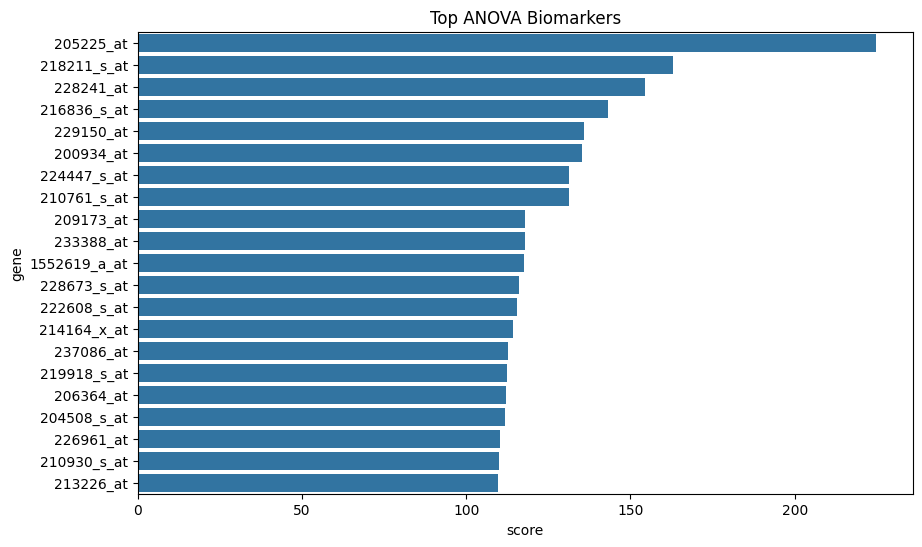

In [8]:
top_anova = anova_scores.head(21)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_anova,
    x="score",
    y="gene"
)

plt.title("Top ANOVA Biomarkers")

plt.show()

# Mutual Information Analysis

## Run MI

In [9]:
mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

## Build Table

In [10]:
mi_df = pd.DataFrame({
    "gene": selected_features,
    "score": mi_scores
})

mi_df = mi_df.sort_values(
    by="score",
    ascending=False
)

mi_df.head()

,gene,score
4858,202240_at,0.779720
13220,213226_at,0.750441
11765,211519_s_at,0.748832
15400,216836_s_at,0.717856
17801,219918_s_at,0.715720


## Plot

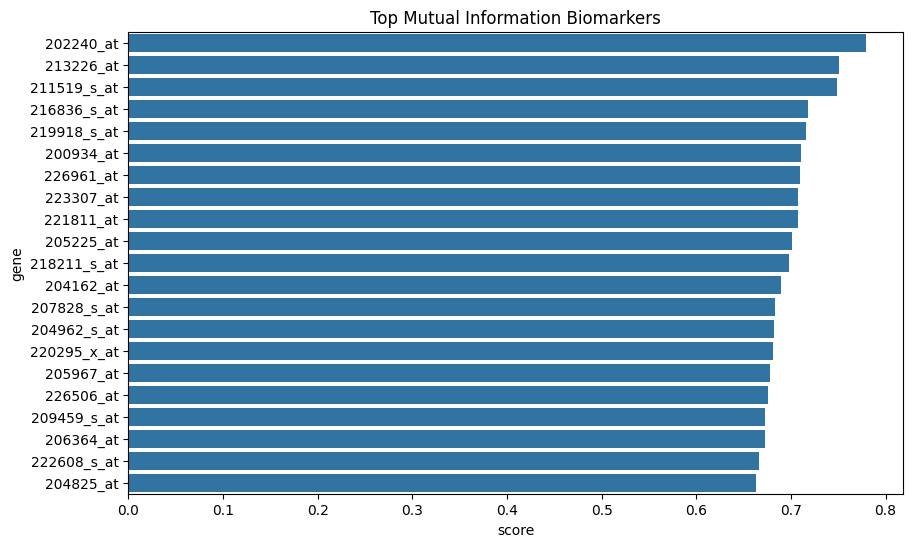

In [11]:
top_mi = mi_df.head(21)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_mi,
    x="score",
    y="gene"
)

plt.title("Top Mutual Information Biomarkers")

plt.show()

# Random Forest Feature Importance

## Train RF

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Extract Importance

In [14]:
rf_importance = pd.DataFrame({
    "gene": selected_features,
    "importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="importance",
    ascending=False
)

rf_importance.head()

,gene,importance
33380,55616_at,0.006027
27939,234354_x_at,0.005794
13411,213441_x_at,0.005297
22462,226197_at,0.005209
11574,211110_s_at,0.004622


## Plot

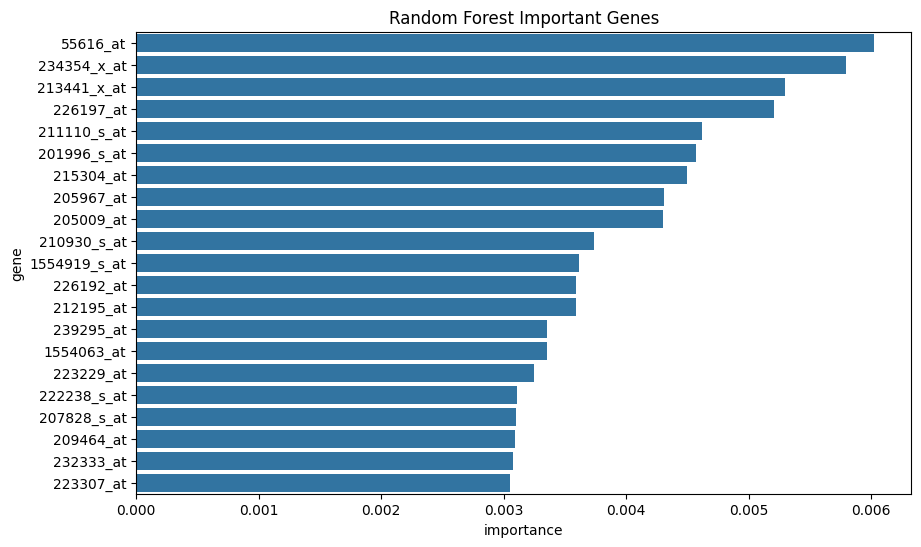

In [15]:
top_rf = rf_importance.head(21)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rf,
    x="importance",
    y="gene"
)

plt.title("Random Forest Important Genes")

plt.show()

# LASSO Feature Selection

## Train LASSO Logistic Regression

In [16]:
lasso = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

lasso.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


## Extract Important Features

In [17]:
lasso_coef = np.abs(lasso.coef_).mean(axis=0)

lasso_importance = pd.DataFrame({
    "gene": selected_features,
    "importance": lasso_coef
})

lasso_importance = lasso_importance.sort_values(
    by="importance",
    ascending=False
)

lasso_importance.head()

,gene,importance
15400,216836_s_at,0.018245
11458,210930_s_at,0.017233
11358,210761_s_at,0.017098
24279,228241_at,0.016233
7592,205225_at,0.016207


## Plot

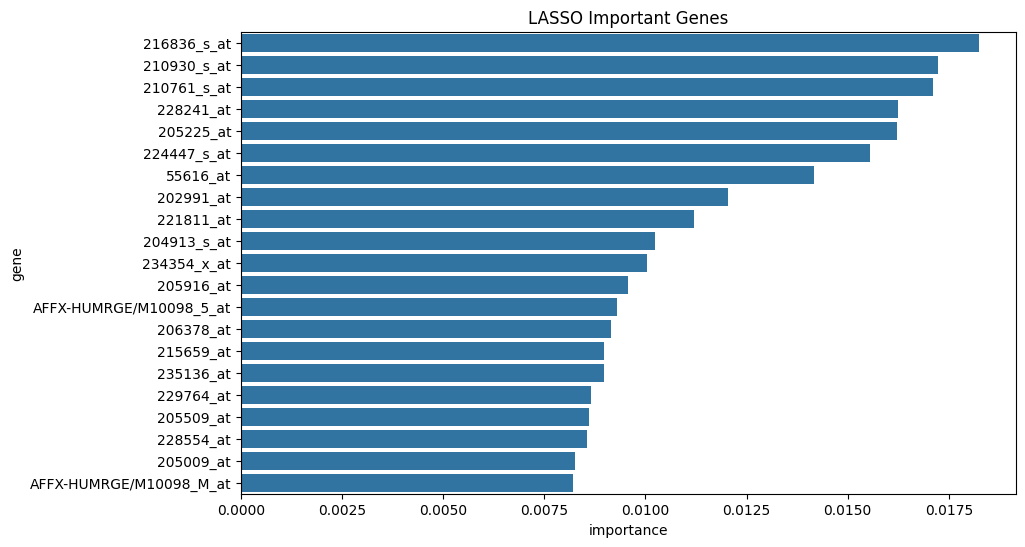

In [18]:
top_lasso = lasso_importance.head(21)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_lasso,
    x="importance",
    y="gene"
)

plt.title("LASSO Important Genes")

plt.show()

# Compare Methods

## Top Genes Per Method

In [19]:
TOP_K = 250

anova_top = set(anova_scores.head(TOP_K)["gene"])
mi_top = set(mi_df.head(TOP_K)["gene"])
rf_top = set(rf_importance.head(TOP_K)["gene"])
lasso_top = set(
    lasso_importance.head(TOP_K)["gene"]
)

from collections import Counter

all_selected = (
    list(anova_top) +
    list(mi_top) +
    list(rf_top) +
    list(lasso_top)
)

gene_counts = Counter(all_selected)

top_consensus = pd.DataFrame(
    gene_counts.items(),
    columns=["gene", "frequency"]
)

top_consensus = top_consensus.sort_values(
    by="frequency",
    ascending=False
)

top_consensus.head(21)

,gene,frequency
62,224447_s_at,4
32,228241_at,4
144,209173_at,4
145,228969_at,4
59,205225_at,4
188,237086_at,4
61,227522_at,4
11,210085_s_at,4
243,55616_at,4
153,214164_x_at,4


## Common Genes

In [20]:
gene_counts.most_common(21)

[('211712_s_at', 4),
 ('210085_s_at', 4),
 ('234354_x_at', 4),
 ('233388_at', 4),
 ('228241_at', 4),
 ('205225_at', 4),
 ('227522_at', 4),
 ('224447_s_at', 4),
 ('219197_s_at', 4),
 ('209173_at', 4),
 ('228969_at', 4),
 ('214164_x_at', 4),
 ('221811_at', 4),
 ('237086_at', 4),
 ('215867_x_at', 4),
 ('210930_s_at', 4),
 ('224428_s_at', 4),
 ('55616_at', 4),
 ('216836_s_at', 3),
 ('208103_s_at', 3),
 ('228673_s_at', 3)]

# Save Artifacts

## Save score tables

In [21]:
anova_scores.to_parquet(
    ARTIFACT_DIR / "anova_scores.parquet",
    index=False
)

mi_df.to_parquet(
    ARTIFACT_DIR / "mi_scores.parquet",
    index=False
)

rf_importance.to_parquet(
    ARTIFACT_DIR / "rf_importance.parquet",
    index=False
)

lasso_importance.to_parquet(
    ARTIFACT_DIR / "lasso_importance.parquet",
    index=False
)
print('Done')

Done


## Save Consensus Genes

In [22]:
top_consensus.to_parquet(
    ARTIFACT_DIR / "consensus_genes.parquet",
    index=False
)

TOP_CONSENSUS_GENES = top_consensus[
    top_consensus["frequency"] >= 2
]["gene"].tolist()

joblib.dump(
    TOP_CONSENSUS_GENES,
    ARTIFACT_DIR / "top_consensus_genes.pkl"
)

print(f"Stable biomarkers: {len(TOP_CONSENSUS_GENES)}")

Stable biomarkers: 231


## Save Feature Selection Models

In [23]:
joblib.dump(
    anova_selector,
    ARTIFACT_DIR / "anova_selector.pkl"
)

joblib.dump(
    rf,
    ARTIFACT_DIR / "rf_model_fs.pkl"
)

joblib.dump(
    lasso,
    ARTIFACT_DIR / "lasso_model.pkl"
)

['C:\\Jupyter Notebook\\PROJECTS\\Breast_cancer_analysis\\data\\artifacts\\lasso_model.pkl']

In [24]:
methods = {
    "ANOVA": anova_top,
    "MI": mi_top,
    "RF": rf_top,
    "LASSO": lasso_top
}

overlap_matrix = pd.DataFrame(
    index=methods.keys(),
    columns=methods.keys()
)

for m1, g1 in methods.items():
    for m2, g2 in methods.items():
        
        overlap = len(g1 & g2)
        
        overlap_matrix.loc[m1, m2] = overlap

overlap_matrix

,ANOVA,MI,RF,LASSO
ANOVA,250,170,91,48
MI,170,250,89,42
RF,91,89,250,33
LASSO,48,42,33,250


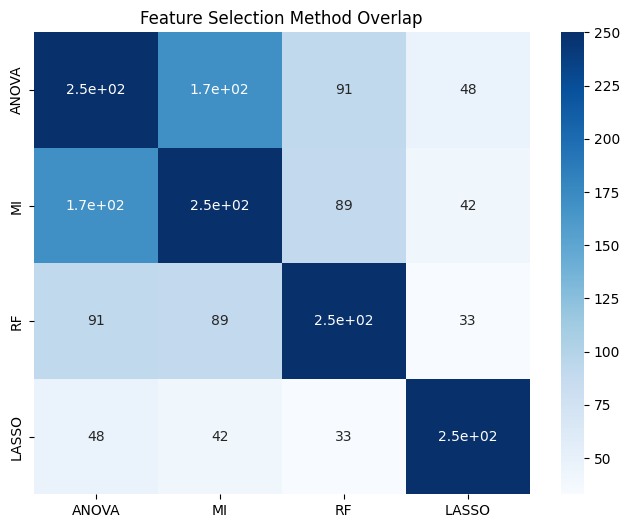

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    overlap_matrix.astype(int),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Selection Method Overlap")

plt.show()